# ERA5-Land Extreme Heat Frequency — Porto Alegre

**Dataset:** ERA5-Land (Copernicus CDS) — `reanalysis-era5-land`  
**Variable:** 2 m air temperature (`t2m`), hourly  
**Resolution:** ~0.1° (~9 km)  
**Period:** DJF seasons 2015–2024 (Dec 2014 → Feb 2024)  
**Product:** Mean annual count of heat-wave days → heat hazard layer

## Methodology

### Metric definition
A **heat-wave day** is any DJF day where the daily maximum 2 m temperature (`T_max`)
exceeds the **local P90 threshold** — i.e., the 90th percentile of all DJF daily-max
values at that grid cell over the 2015–2024 period.

Using a local (pixel-level) threshold rather than a fixed absolute temperature
captures **relative anomalies** within the city: areas that are systematically
hotter than their own long-term summer distribution.

### Processing steps
1. Download ERA5-Land hourly `t2m` for DJF months (Dec–Feb), 2014–2024, over the Porto Alegre bounding box via CDS API.
2. Compute daily maximum temperature (`T_max`) from 24 hourly values; convert from Kelvin to °C.
3. Assign DJF seasons: Dec(Y−1) + Jan(Y) + Feb(Y) = DJF season Y.
4. Compute the **local P90 threshold** per grid cell across all DJF days (2015–2024).
5. For each DJF season, count days where `T_max > P90_local` → `hw_days_per_season`.
6. Average across the 10 seasons → `hw_freq_mean` (mean annual heat-wave day count).
7. Min-max normalization within POA → `hw_norm` (0–1, input for heat hazard ensemble).

### Outputs
| File | Description |
|------|-------------|
| `era5_hw_freq_djf_2015_2024_poa.tif` | Mean annual heat-wave days (count) |
| `era5_hw_norm_djf_2015_2024_poa.tif` | Min-max normalized frequency (0–1) |

In [ ]:
# Site configuration — uses transformation/heat_hazard city configs
import os
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
_HEAT_HAZARD = None
for _candidate in [_HERE, *_HERE.parents]:
    _probe = _candidate / "heat_hazard" if _candidate.name != "heat_hazard" else _candidate
    if (_probe / "site_config.py").is_file() and (_probe / "config" / "sites").is_dir():
        _HEAT_HAZARD = _probe
        break
if _HEAT_HAZARD is None:
    raise FileNotFoundError("Could not locate transformation/heat_hazard from notebook cwd")

sys.path.insert(0, str(_HEAT_HAZARD))
from site_config import load_site_config

HEAT_HAZARD_ROOT = _HEAT_HAZARD
HEAT_ROOT = HEAT_HAZARD_ROOT  # backward-compatible alias

# Set the city here (edit this line). That value wins for interactive runs.
# Use None to fall back to env HEAT_SITE (default porto_alegre).
SITE_SLUG = "plymouth"  # or: "porto_alegre" | "edina" | "richfield" | "rochester" | "apple_valley" | None
if SITE_SLUG is None:
    SITE_SLUG = os.environ.get("HEAT_SITE", "porto_alegre")
SITE_CONFIG = load_site_config(SITE_SLUG, HEAT_HAZARD_ROOT)
SITE_ROOT = SITE_CONFIG["paths_abs"]["site_root"]
INPUT_DIR = SITE_CONFIG["paths_abs"]["data_input"]
INTERMEDIATE_DIR = SITE_CONFIG["paths_abs"]["data_intermediate"]
OUTPUT_DIR = SITE_CONFIG["paths_abs"]["data_output"]
OUT_ROOT = SITE_CONFIG["paths_abs"]["out"]
CACHE_DIR = SITE_CONFIG["paths_abs"]["cache"]
STYLES_DIR = SITE_CONFIG["paths_abs"]["styles"]
OUTPUT_PREFIX = SITE_CONFIG["output_prefix"]
SEASON = SITE_CONFIG["season"]
SEASON_LABEL = SITE_CONFIG["season_label"]
START_YEAR = int(SITE_CONFIG["start_year"])
END_YEAR = int(SITE_CONFIG["end_year"])
print(f"Heat hazard site: {SITE_CONFIG['display_name']} ({SITE_SLUG})")
print(f"Config: {SITE_CONFIG['config_path']}")
print(f"Season: {SEASON_LABEL} {START_YEAR}-{END_YEAR}")
print(f"Inputs -> {INPUT_DIR}")


## 0. Setup

In [9]:
import cdsapi
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import rasterio
from rasterio.transform import from_bounds
from pathlib import Path
import zipfile
import shutil
import warnings
warnings.filterwarnings('ignore')

## 1. Parameters & paths

In [ ]:
# Porto Alegre bounding box
LON_MIN, LON_MAX = -51.30344, -51.018852
LAT_MIN, LAT_MAX = -30.26945, -29.932474

# CDS area format: [North, West, South, East]
CDS_AREA = [LAT_MAX, LON_MIN, LAT_MIN, LON_MAX]

# DJF seasons to analyse (DJF_Y = Dec(Y-1) + Jan(Y) + Feb(Y))
SEASONS = list(range(2015, 2025))   # 2015 … 2024  →  10 seasons

# Paths
BASE_DIR   = HEAT_ROOT
DATA_DIR   = CACHE_DIR / 'era5_land'
OUTPUT_DIR = OUTPUT_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Data dir   :', DATA_DIR)
print('Output dir :', OUTPUT_DIR)
print('Seasons    :', SEASONS)


## 2. Download ERA5-Land via CDS API

Downloads one NetCDF file per DJF season (Dec of year Y−1 + Jan–Feb of year Y).  
Files are cached — already-downloaded seasons are skipped.

> **Prerequisites:** `~/.cdsapirc` must contain your CDS API URL and key.  
> See https://cds.climate.copernicus.eu/how-to-api for setup instructions.

In [11]:
c = cdsapi.Client()


def _unzip_cds_file(zip_path: Path, out_path: Path) -> None:
    """
    The new CDS API wraps the NetCDF in a ZIP archive (data_0.nc inside).
    Extract it and rename to the expected .nc path.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        members = zf.namelist()
        nc_member = next((m for m in members if m.endswith('.nc')), members[0])
        extracted = zip_path.parent / nc_member
        zf.extract(nc_member, zip_path.parent)
    shutil.move(str(extracted), str(out_path))


def download_djf_season(season_year: int, out_dir: Path) -> Path:
    """Download hourly t2m for DJF season_year (Dec(Y-1) + Jan-Feb(Y)).
    Handles the new CDS API that returns a ZIP containing data_0.nc.
    """
    out_file = out_dir / f'era5_land_t2m_{SEASON}{season_year}_{OUTPUT_PREFIX}.nc'

    # If cached file is actually a ZIP from a previous run, fix it now
    if out_file.exists():
        with open(out_file, 'rb') as f:
            magic = f.read(4)
        if magic == b'PK\x03\x04':   # ZIP magic bytes
            print(f'  DJF {season_year}: cached file is a ZIP — extracting …')
            tmp_zip = out_file.with_suffix('.zip')
            shutil.copy(str(out_file), str(tmp_zip))
            out_file.unlink()
            _unzip_cds_file(tmp_zip, out_file)
            tmp_zip.unlink()
            print(f'  DJF {season_year}: extracted → {out_file.name}')
        else:
            print(f'  DJF {season_year}: cached ({out_file.name})')
        return out_file

    # Download (CDS returns a ZIP; we save it as a temp .zip then extract)
    tmp_zip = out_dir / f'era5_land_t2m_{SEASON}{season_year}_{OUTPUT_PREFIX}_tmp.zip'
    request = {
        'product_type': 'reanalysis',
        'variable': '2m_temperature',
        'year':  [str(season_year - 1), str(season_year)],
        'month': ['12', '01', '02'],
        'day':   [f'{d:02d}' for d in range(1, 32)],
        'time':  [f'{h:02d}:00' for h in range(0, 24)],
        'area':  CDS_AREA,
        'format': 'netcdf',
    }
    print(f'  DJF {season_year}: downloading …')
    c.retrieve('reanalysis-era5-land', request, str(tmp_zip))

    # Extract NetCDF from ZIP
    _unzip_cds_file(tmp_zip, out_file)
    tmp_zip.unlink()
    print(f'  DJF {season_year}: saved → {out_file.name}')
    return out_file


print('Downloading ERA5-Land t2m for DJF seasons 2015–2024 …')
nc_files = []
for yr in SEASONS:
    nc_files.append(download_djf_season(yr, DATA_DIR))

print(f'\nAll {len(nc_files)} files ready.')


  DJF 2015: cached (era5_land_t2m_djf2015_poa.nc)
  DJF 2016: cached (era5_land_t2m_djf2016_poa.nc)
  DJF 2017: cached (era5_land_t2m_djf2017_poa.nc)
  DJF 2018: cached (era5_land_t2m_djf2018_poa.nc)
  DJF 2019: cached (era5_land_t2m_djf2019_poa.nc)
  DJF 2020: cached (era5_land_t2m_djf2020_poa.nc)
  DJF 2021: cached (era5_land_t2m_djf2021_poa.nc)
  DJF 2022: cached (era5_land_t2m_djf2022_poa.nc)
  DJF 2023: cached (era5_land_t2m_djf2023_poa.nc)
  DJF 2024: cached (era5_land_t2m_djf2024_poa.nc)

All 10 files ready.


## 3. Load & compute daily maximum temperature

Hourly `t2m` (Kelvin) → daily max → °C  
Also filters each file to the correct three DJF months
(each file may contain some extra days from the CDS request).

In [12]:
def load_season(nc_file: Path, season_year: int) -> xr.DataArray:
    """
    Load a DJF season file, filter to correct months,
    compute daily max T2m (°C), and tag with season year.

    Handles the new CDS API format where the time coordinate is named
    'valid_time' instead of 'time'.
    """
    ds = xr.open_dataset(nc_file, engine='netcdf4')

    # ── Normalise time coordinate name (new CDS API uses 'valid_time') ────────
    if 'valid_time' in ds.coords and 'time' not in ds.coords:
        ds = ds.rename({'valid_time': 'time'})
    elif 'valid_time' in ds.dims and 'time' not in ds.dims:
        ds = ds.rename({'valid_time': 'time'})

    # ── Variable name ('t2m' in old format, may differ in new format) ─────────
    # New CDS format may have 't2m' as a data variable without 'expver' issues
    varname = None
    for candidate in ['t2m', 'VAR_2T', 'temperature']:
        if candidate in ds:
            varname = candidate
            break
    if varname is None:
        varname = list(ds.data_vars)[0]   # fallback: first data variable

    t2m = ds[varname]  # Kelvin, dims: (time, latitude, longitude)

    # ── Filter to the correct DJF months ─────────────────────────────────────
    valid_months = [
        (season_year - 1, 12),
        (season_year,      1),
        (season_year,      2),
    ]
    mask = np.array([
        (int(t.dt.year), int(t.dt.month)) in valid_months
        for t in t2m.time
    ])
    t2m = t2m.isel(time=mask)

    # ── Daily max: group by date → max of 24 hourly values ───────────────────
    t2m_daily_max = (
        t2m
        .resample(time='1D')
        .max(skipna=True)
        .rename('tmax_celsius')
    )

    # ── Kelvin → Celsius ──────────────────────────────────────────────────────
    t2m_daily_max = t2m_daily_max - 273.15

    # Tag with season year
    t2m_daily_max = t2m_daily_max.assign_coords(season=season_year)
    return t2m_daily_max


# Load all seasons
season_arrays = []
for yr, nc_file in zip(SEASONS, nc_files):
    da = load_season(nc_file, yr)
    season_arrays.append(da)
    print(f'  DJF {yr}: {len(da.time)} days, '
          f'T_max range [{float(da.min()):.1f}, {float(da.max()):.1f}] °C')

# Concatenate all DJF days across seasons into one DataArray
tmax_all = xr.concat(season_arrays, dim='time')
print(f'\nTotal DJF days across all seasons: {len(tmax_all.time)}')
print(f'Grid shape: {tmax_all.latitude.size} lat × {tmax_all.longitude.size} lon')
print(f'Lat range : {float(tmax_all.latitude.min()):.2f} → {float(tmax_all.latitude.max()):.2f}')
print(f'Lon range : {float(tmax_all.longitude.min()):.2f} → {float(tmax_all.longitude.max()):.2f}')

  DJF 2015: 90 days, T_max range [23.1, 34.8] °C
  DJF 2016: 91 days, T_max range [22.2, 36.2] °C
  DJF 2017: 90 days, T_max range [22.5, 36.7] °C
  DJF 2018: 90 days, T_max range [21.4, 37.1] °C
  DJF 2019: 90 days, T_max range [19.9, 38.1] °C
  DJF 2020: 91 days, T_max range [21.9, 38.3] °C
  DJF 2021: 90 days, T_max range [20.5, 38.4] °C
  DJF 2022: 90 days, T_max range [22.8, 39.0] °C
  DJF 2023: 90 days, T_max range [21.7, 37.5] °C
  DJF 2024: 91 days, T_max range [21.8, 37.2] °C

Total DJF days across all seasons: 903
Grid shape: 3 lat × 3 lon
Lat range : -30.20 → -30.00
Lon range : -51.30 → -51.10


## 4. Local P90 threshold

Compute the 90th percentile of `T_max` over **all DJF days (2015–2024)** at each grid cell independently.  
This gives a spatially varying threshold that reflects the local summer climate.

In [13]:
# P90 threshold per pixel across all DJF days
p90_threshold = tmax_all.quantile(0.90, dim='time').rename('p90_celsius')

print('Local P90 T_max (°C) — grid statistics:')
print(f'  Min  : {float(p90_threshold.min()):.2f}')
print(f'  Mean : {float(p90_threshold.mean()):.2f}')
print(f'  Max  : {float(p90_threshold.max()):.2f}')
print()
print('P90 per grid cell:')
print(p90_threshold.values.round(2))

Local P90 T_max (°C) — grid statistics:
  Min  : 33.04
  Mean : 33.63
  Max  : 34.10

P90 per grid cell:
[[34.1  33.92 33.7 ]
 [33.94 33.57 33.4 ]
 [  nan 33.38 33.04]]


## 5. Heat-wave day count per season

For each DJF season, count how many days have `T_max > P90_local` at each grid cell.  
Then average across the 10 seasons to get the **mean annual heat-wave day count**.

In [14]:
hw_counts = []  # one DataArray per season

for yr, da in zip(SEASONS, season_arrays):
    # Boolean: True where T_max exceeds local P90
    exceeds = (da > p90_threshold).sum(dim='time').rename('hw_days')
    exceeds = exceeds.assign_coords(season=yr)
    hw_counts.append(exceeds)
    print(f'  DJF {yr}: mean hw_days = {float(exceeds.mean()):.1f}  '
          f'[{int(exceeds.min())} – {int(exceeds.max())}] across grid cells')

# Stack into (season, lat, lon)
hw_seasonal = xr.concat(hw_counts, dim='season')

# Mean annual heat-wave day count
hw_freq_mean = hw_seasonal.mean(dim='season').rename('hw_freq_mean')

print()
print('Mean annual heat-wave days (2015–2024):')
print(f'  Min  : {float(hw_freq_mean.min()):.2f}')
print(f'  Mean : {float(hw_freq_mean.mean()):.2f}')
print(f'  Max  : {float(hw_freq_mean.max()):.2f}')
print()
print('Per grid cell:')
print(hw_freq_mean.values.round(2))

  DJF 2015: mean hw_days = 3.3  [0 – 6] across grid cells
  DJF 2016: mean hw_days = 3.2  [0 – 4] across grid cells
  DJF 2017: mean hw_days = 4.1  [0 – 5] across grid cells
  DJF 2018: mean hw_days = 3.4  [0 – 5] across grid cells
  DJF 2019: mean hw_days = 13.7  [0 – 17] across grid cells
  DJF 2020: mean hw_days = 13.4  [0 – 16] across grid cells
  DJF 2021: mean hw_days = 3.6  [0 – 4] across grid cells
  DJF 2022: mean hw_days = 17.8  [0 – 20] across grid cells
  DJF 2023: mean hw_days = 10.1  [0 – 14] across grid cells
  DJF 2024: mean hw_days = 8.2  [0 – 11] across grid cells

Mean annual heat-wave days (2015–2024):
  Min  : 0.00
  Mean : 8.09
  Max  : 9.10

Per grid cell:
[[9.1 9.1 9.1]
 [9.1 9.1 9.1]
 [0.  9.1 9.1]]


## 6. Summary statistics

Quick tabular summary of all three key layers.

In [15]:
layers_stats = {
    'T_max P90 threshold (°C)':    p90_threshold,
    'HW days / season (mean count)': hw_freq_mean,
}

print(f"{'Layer':<35} {'Min':>8} {'Mean':>8} {'Max':>8}")
print('-' * 62)
for label, da in layers_stats.items():
    print(f"{label:<35} {float(da.min()):>8.2f} {float(da.mean()):>8.2f} {float(da.max()):>8.2f}")

Layer                                    Min     Mean      Max
--------------------------------------------------------------
T_max P90 threshold (°C)               33.04    33.63    34.10
HW days / season (mean count)           0.00     8.09     9.10


## 7. Min-max normalization

Scale `hw_freq_mean` to [0, 1] using the grid's own min and max.  
This is the layer used as input to the heat hazard ensemble.

```
hw_norm = (hw_freq_mean − min) / (max − min)
```

In [16]:
grid_min = float(hw_freq_mean.min())
grid_max = float(hw_freq_mean.max())

if grid_max > grid_min:
    hw_norm = ((hw_freq_mean - grid_min) / (grid_max - grid_min)).rename('hw_norm')
else:
    # Degenerate case: all cells identical → uniform 0.5
    hw_norm = xr.ones_like(hw_freq_mean).rename('hw_norm') * 0.5
    print('WARNING: all grid cells have the same hw_freq_mean — assigning 0.5 uniformly.')

print(f"{'Layer':<35} {'Min':>8} {'Mean':>8} {'Max':>8}")
print('-' * 62)
print(f"{'HW norm (0–1)':<35} {float(hw_norm.min()):>8.3f} {float(hw_norm.mean()):>8.3f} {float(hw_norm.max()):>8.3f}")

Layer                                    Min     Mean      Max
--------------------------------------------------------------
HW norm (0–1)                          0.000    0.889    1.000


## 8. Visualize

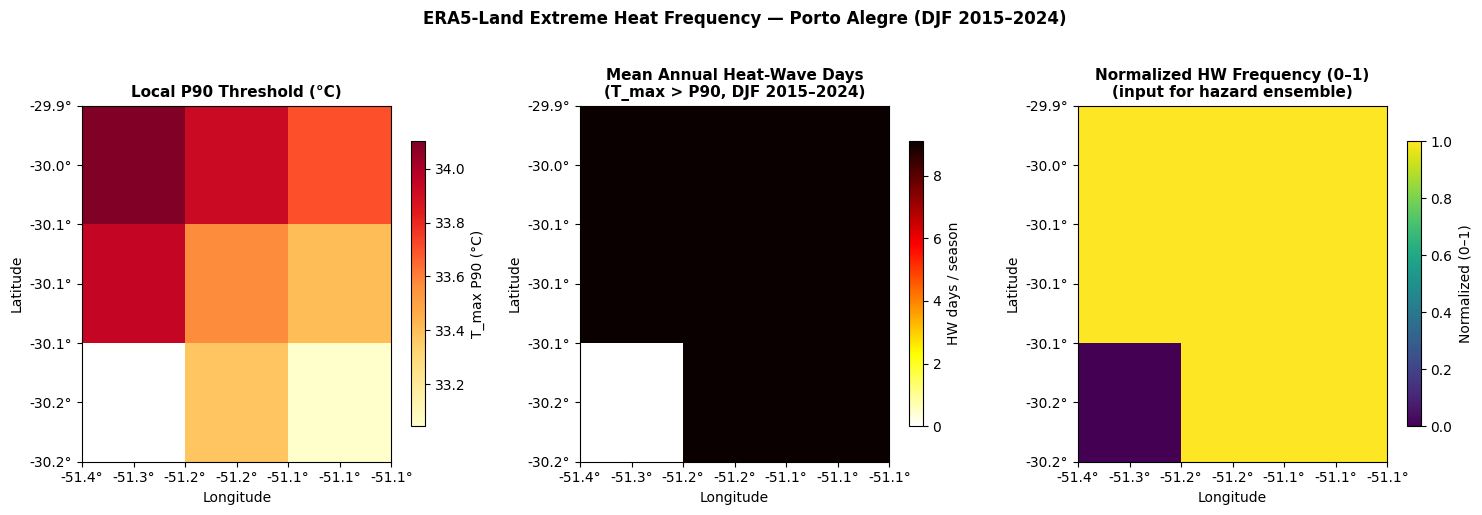

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Helper: add coastline/grid ticks
def style_ax(ax, title):
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f°'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f°'))

# Panel 1 — P90 threshold
im0 = p90_threshold.plot(
    ax=axes[0], cmap='YlOrRd', add_colorbar=False,
)
plt.colorbar(im0, ax=axes[0], label='T_max P90 (°C)', shrink=0.8)
style_ax(axes[0], 'Local P90 Threshold (°C)')

# Panel 2 — Mean annual heat-wave days
im1 = hw_freq_mean.plot(
    ax=axes[1], cmap='hot_r', add_colorbar=False,
)
plt.colorbar(im1, ax=axes[1], label='HW days / season', shrink=0.8)
style_ax(axes[1], 'Mean Annual Heat-Wave Days\n(T_max > P90, DJF 2015–2024)')

# Panel 3 — Normalized
im2 = hw_norm.plot(
    ax=axes[2], cmap='viridis', vmin=0, vmax=1, add_colorbar=False,
)
plt.colorbar(im2, ax=axes[2], label='Normalized (0–1)', shrink=0.8)
style_ax(axes[2], 'Normalized HW Frequency (0–1)\n(input for hazard ensemble)')

fig.suptitle(
    'ERA5-Land Extreme Heat Frequency — Porto Alegre (DJF 2015–2024)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### Annual heat-wave day count per season

Small-multiples view: one panel per DJF season to inspect inter-annual variability.

## 10. Convert ERA5 Heat-Wave Frequency to COG and Generate Tiles

Publish the local `sites/<site_slug>/data/input/era5_hw_freq_djf_2015_2024_poa.tif` raster for web maps: COG + colorized XYZ tiles + value-encoded XYZ tiles for hover lookup.

Requires GDAL CLI (`gdal_translate`, `gdaldem`, `gdal_calc.py`, `gdal2tiles.py`) and `sites/<site_slug>/data/output/era5_hw_freq_djf_2015_2024_poa_colors.txt`.

In [ ]:
# Convert ERA5-Land heat-wave frequency GeoTIFF to COG + visual tiles + value tiles.
from pathlib import Path
import shutil
import subprocess



PROJECT_ROOT = HEAT_HAZARD_ROOT
in_tif = INPUT_DIR / SITE_CONFIG["layers"]["era5_hw_freq"]
slug = SITE_CONFIG["layers"]["era5_hw_freq"].removesuffix(".tif")
out_dir = OUT_ROOT / slug
colors_txt = STYLES_DIR / f"{slug}_colors.txt"
cog_tif = out_dir / f"{slug}_cog.tif"
colorized_tif = out_dir / f"{slug}_colorized.tif"
value_encoded_tif = out_dir / f"{slug}_value_encoded_rgb.tif"
tiles_dir = out_dir / "tiles_visual"
value_tiles_dir = out_dir / "tiles_values"
decode_txt = out_dir / f"{slug}_value_tiles_decode.txt"

out_dir.mkdir(parents=True, exist_ok=True)
if not in_tif.exists():
    raise FileNotFoundError(f"Missing input raster: {in_tif}")
if not colors_txt.exists():
    raise FileNotFoundError(f"Missing color table: {colors_txt}")

print("Input:", in_tif)
print("Output dir:", out_dir)

# 1) COG preserving raw mean annual heat-wave day counts.
subprocess.run([
    "gdal_translate", str(in_tif), str(cog_tif),
    "-of", "COG",
    "-ot", "Float32",
    "-co", "COMPRESS=DEFLATE",
    "-co", "RESAMPLING=NEAREST",
    "-co", "OVERVIEWS=AUTO",
], check=True)
print("Created COG:", cog_tif)

# 2) Colorized raster + visual XYZ tiles.
subprocess.run([
    "gdaldem", "color-relief",
    str(cog_tif), str(colors_txt), str(colorized_tif),
    "-alpha",
], check=True)
print("Created colorized raster:", colorized_tif)

# gdal2tiles preflight: use the Python interpreter referenced by gdal2tiles.py.
gdal2tiles = shutil.which("gdal2tiles.py")
if not gdal2tiles:
    raise RuntimeError("gdal2tiles.py not found in PATH. Install GDAL (e.g. brew install gdal).")

gdal2tiles_python = None
with open(gdal2tiles, "r", encoding="utf-8", errors="ignore") as f:
    first_line = f.readline().strip()
if first_line.startswith("#!"):
    shebang_parts = first_line[2:].split()
    if shebang_parts:
        if shebang_parts[0].endswith("env") and len(shebang_parts) > 1:
            gdal2tiles_python = shutil.which(shebang_parts[1])
        else:
            gdal2tiles_python = shebang_parts[0]
if not gdal2tiles_python:
    gdal2tiles_python = shutil.which("python3") or shutil.which("python")
subprocess.run([gdal2tiles_python, "-c", "import numpy"], check=True, capture_output=True)

tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    "gdal2tiles.py",
    "-r", "near",
    "-z", "8-15",
    "--xyz",
    "-w", "none",
    str(colorized_tif),
    str(tiles_dir),
], check=True)
print("Visual tiles:", tiles_dir)

# 3) Value tiles for client-side hover.
# Encodes mean annual heat-wave days at 0.01-day precision plus 1 so encoded RGB value 0 can mean nodata.
# Decode: encoded = R + 256*G + 65536*B; hw_days = (encoded - 1) / 100; encoded == 0 => nodata.
base_expr = (
    "numpy.where(numpy.isnan(A), 0, "
    "numpy.rint(numpy.clip(A,0,167772.14)*100).astype(numpy.int64) + 1)"
)
subprocess.run([
    "gdal_calc.py",
    "-A", str(cog_tif),
    "--calc", f"bitwise_and({base_expr},255)",
    "--calc", f"bitwise_and(right_shift({base_expr},8),255)",
    "--calc", f"bitwise_and(right_shift({base_expr},16),255)",
    "--type", "Byte",
    "--NoDataValue", "0",
    "--overwrite",
    "--outfile", str(value_encoded_tif),
], check=True)

value_tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    "gdal2tiles.py",
    "-r", "near",
    "-z", "8-15",
    "--xyz",
    "-w", "none",
    str(value_encoded_tif),
    str(value_tiles_dir),
], check=True)

metadata = """ERA5-Land heat-wave frequency value tiles

Source raster: sites/<site_slug>/data/input/era5_hw_freq_djf_2015_2024_poa.tif
COG: sites/<site_slug>/data/output/era5_hw_freq_djf_2015_2024_poa/era5_hw_freq_djf_2015_2024_poa_cog.tif
Visual tiles: sites/<site_slug>/data/output/era5_hw_freq_djf_2015_2024_poa/tiles_visual/{z}/{x}/{y}.png
Value tiles: sites/<site_slug>/data/output/era5_hw_freq_djf_2015_2024_poa/tiles_values/{z}/{x}/{y}.png

Value tile encoding:
encoded = R + 256 * G + 65536 * B
if encoded == 0: value is nodata
else: hw_days = (encoded - 1) / 100

Values are mean annual DJF heat-wave day counts where daily Tmax exceeds the local P90 threshold, encoded at 0.01-day precision.
"""
decode_txt.write_text(metadata, encoding="utf-8")

print("Value tiles:", value_tiles_dir)
print("Decode metadata:", decode_txt)
print("Decode: encoded = R + 256*G + 65536*B; hw_days = (encoded - 1) / 100; encoded 0 = nodata")


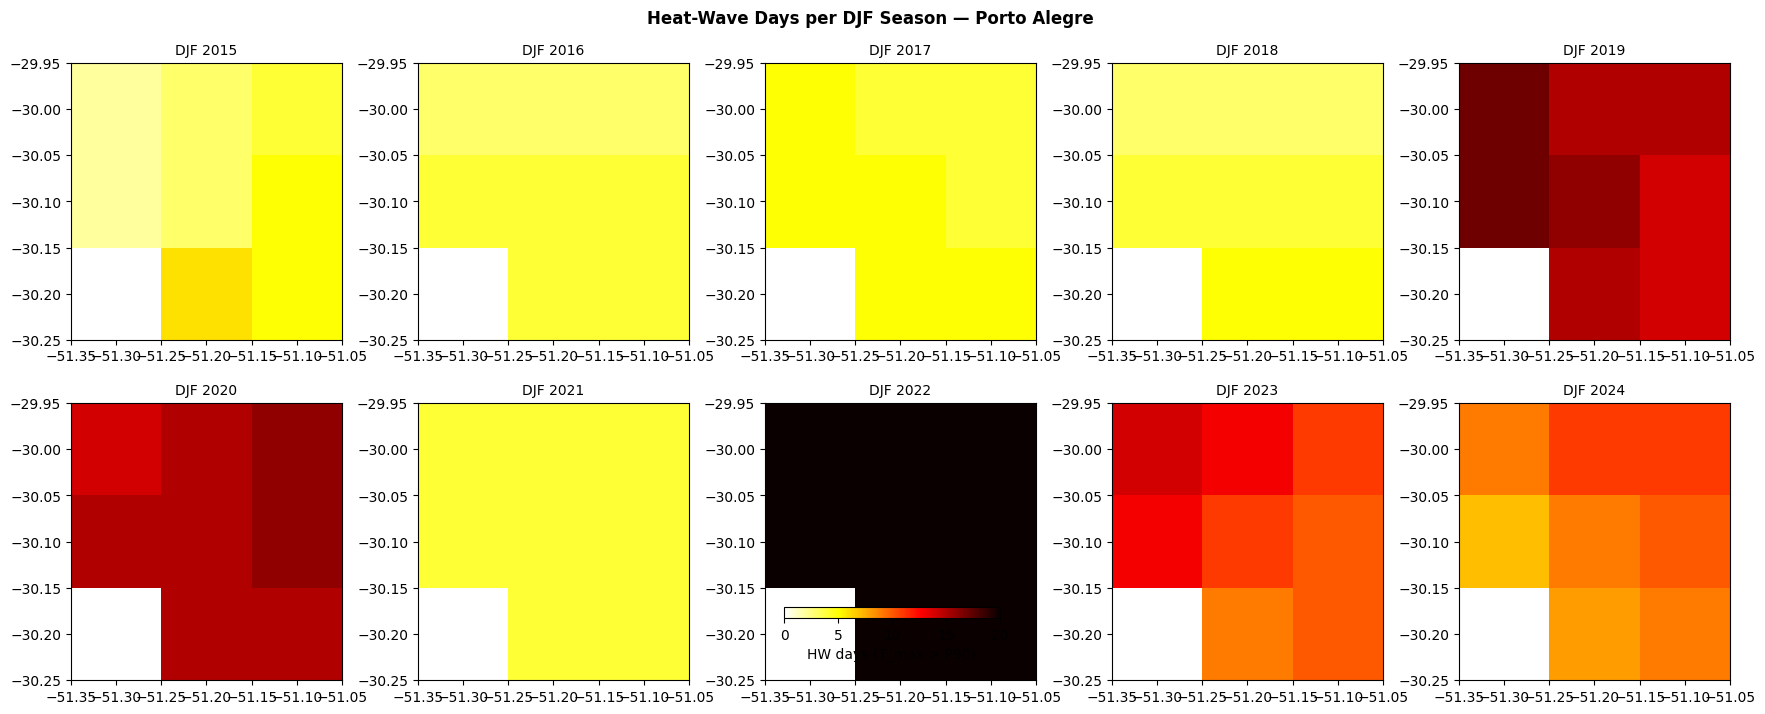

In [18]:
n_seasons = len(SEASONS)
ncols = 5
nrows = int(np.ceil(n_seasons / ncols))

vmax_hw = int(hw_seasonal.max())

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = axes.flatten()

for i, (yr, da) in enumerate(zip(SEASONS, hw_counts)):
    im = da.plot(
        ax=axes[i], cmap='hot_r', vmin=0, vmax=vmax_hw,
        add_colorbar=False,
    )
    axes[i].set_title(f'DJF {yr}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.colorbar(
    im, ax=axes[:n_seasons], label='HW days (T_max > P90)',
    orientation='horizontal', fraction=0.02, pad=0.08
)
fig.suptitle(
    'Heat-Wave Days per DJF Season — Porto Alegre',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 9. Export GeoTIFFs

Saves two GeoTIFFs at native ERA5-Land resolution (~0.1°) in EPSG:4326:

| File | Layer |
|------|-------|
| `era5_hw_freq_djf_2015_2024_poa.tif` | Mean annual heat-wave day count |
| `era5_hw_norm_djf_2015_2024_poa.tif` | Normalized frequency (0–1) |

In [19]:
def export_geotiff(da: xr.DataArray, out_path: Path, nodata: float = -9999.0) -> None:
    """
    Write a 2-D DataArray (latitude × longitude) to a GeoTIFF.
    Assumes latitude is decreasing (north → south) as in ERA5-Land.
    """
    # Ensure latitude is decreasing (north-up raster)
    if float(da.latitude[0]) < float(da.latitude[-1]):
        da = da.isel(latitude=slice(None, None, -1))

    data = da.values.astype(np.float32)
    lats = da.latitude.values
    lons = da.longitude.values

    res_lon = float(lons[1] - lons[0])
    res_lat = float(lats[0] - lats[1])   # positive number (north-up)

    # Upper-left corner at pixel edge
    west  = float(lons[0])  - res_lon / 2
    north = float(lats[0])  + res_lat / 2

    transform = rasterio.transform.from_origin(west, north, res_lon, res_lat)

    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=data.shape[0],
        width=data.shape[1],
        count=1,
        dtype='float32',
        crs='EPSG:4326',
        transform=transform,
        nodata=nodata,
    ) as dst:
        dst.write(data, 1)

    print(f'Exported: {out_path.name}  ({data.shape[0]} rows × {data.shape[1]} cols)')


export_geotiff(
    hw_freq_mean,
    OUTPUT_DIR / SITE_CONFIG['layers']['era5_hw_freq']
)
export_geotiff(
    hw_norm,
    OUTPUT_DIR / SITE_CONFIG['layers']['era5_hw_norm']
)

print('\nDone.')


Exported: era5_hw_freq_djf_2015_2024_poa.tif  (3 rows × 3 cols)
Exported: era5_hw_norm_djf_2015_2024_poa.tif  (3 rows × 3 cols)

Done.
